In [1]:
# استيراد المكتبات الأساسية
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# إعدادات العرض
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print("✅ تم تحميل المكتبات بنجاح!")

✅ تم تحميل المكتبات بنجاح!


In [2]:
# Download Titanic data
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print("تم تحميل البيانات بنجاح!")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

تم تحميل البيانات بنجاح!
Number of rows: 891
Number of columns: 12


In [3]:
print(" A first look at the data :")
df.head()

 A first look at the data :


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Detailed information about the data
print("📋 Information about columns and data types:")
df.info()

📋 Information about columns and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Descriptive statistics for digital columns
print("📊 الإحصائيات الوصفية:")
df.describe()

📊 الإحصائيات الوصفية:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Check for missing values
print(": حانفتش القيم المفقودة ")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Number of missing values': missing_values.values,
    'Percentage': missing_percentage.values
})

missing_df = missing_df[missing_df['Number of missing values'] > 0].sort_values('Number of missing values', ascending=False)

print(missing_df)

: حانفتش القيم المفقودة 
      Column  Number of missing values  Percentage
10     Cabin                       687   77.104377
5        Age                       177   19.865320
11  Embarked                         2    0.224467


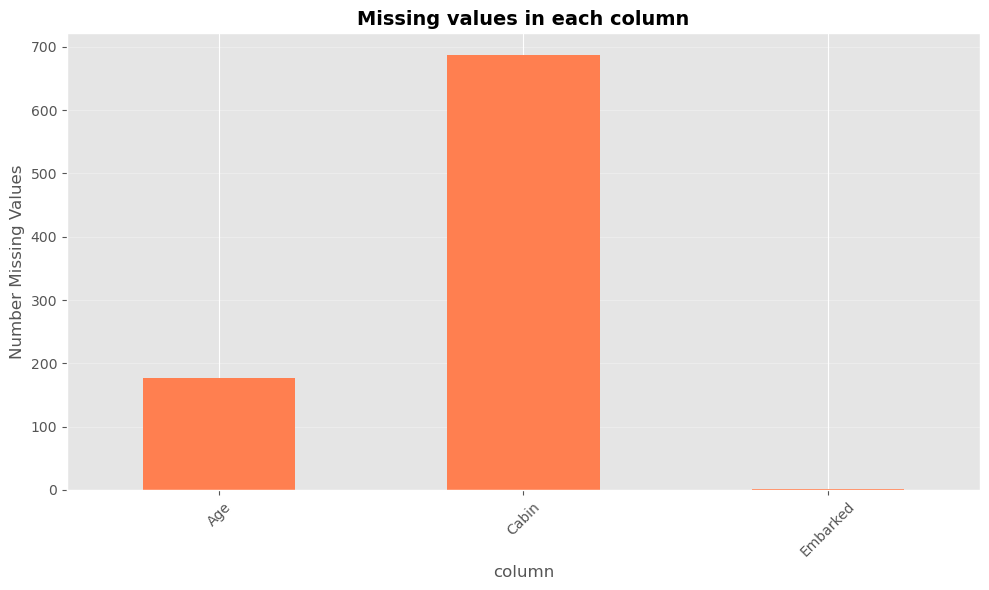

: Total missing values 866


In [7]:
# Visualize missing values
plt.figure(figsize=(10, 6))
missing_data = df.isnull().sum()[df.isnull().sum() > 0]
missing_data.plot(kind='bar', color='coral')
plt.title('Missing values ​​in each column', fontsize=14, fontweight='bold')
plt.xlabel('column')
plt.ylabel('Number Missing Values')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(f": Total missing values {df.isnull().sum().sum()}")

In [8]:
# Age processing - We fill it with the average (Median) because it is more resistant to outliers.
print(f" Before processing - Age missing: {df['Age'].isnull().sum()}")

# Calculate the average
median_age = df['Age'].median()
print(f"Average age : {median_age}")

#Fill in missing values
df['Age'].fillna(median_age, inplace=True)

print(f"✅ After processing - Age missing: {df['Age'].isnull().sum()}")

 Before processing - Age missing: 177
Average age : 28.0
✅ After processing - Age missing: 0


In [9]:
# Embarked processing - We fill it with the most frequently occurring value (Mode)
print(f"Before processing - Embarked missing: {df['Embarked'].isnull().sum()}")
#Finding the most frequently occurring value
mode_embarked = df['Embarked'].mode()[0]
print(f"the most frequently occurring value: {mode_embarked}")
df['Embarked'].fillna(mode_embarked, inplace=True)
print(f"After processing - Embarked missing: {df['Embarked'].isnull().sum()}")

Before processing - Embarked missing: 2
the most frequently occurring value: S
After processing - Embarked missing: 0


In [10]:
# Cabin contains too many missing values ​​(77%)
# Solution: We delete the column because it won't be very useful to us.
print(f" Cabin missing: {df['Cabin'].isnull().sum()} ({(df['Cabin'].isnull().sum()/len(df)*100):.1f}%)")

df.drop('Cabin', axis=1, inplace=True)

print(" تم حذف عمود Cabin")
print(f" عدد الأعمدة الآن: {df.shape[1]}")

 Cabin missing: 687 (77.1%)
 تم حذف عمود Cabin
 عدد الأعمدة الآن: 11


In [11]:
# Checking for duplicate rows
duplicates = df.duplicated().sum()
print(f" Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    
    print(f"✅ {duplicates} duplicate row removed")
else:
    print("✅ No duplicate rows!")
    
print(f" Number of rows after processing: {df.shape[0]}")

 Number of duplicate rows: 0
✅ No duplicate rows!
 Number of rows after processing: 891


In [12]:
# Final verification
print("Final check for missing values:")
print(df.isnull().sum())
print("\n" + "="*50)
print(f"✅ Total remaining missing values: {df.isnull().sum().sum()}")

Final check for missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

✅ Total remaining missing values: 0


In [13]:
# Converting Sex to Numbers (Male=1, Female=0)

print(" Convert Sex:")
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
print(df['Sex'].value_counts())

print("\n تحويل Embarked:")
# تحويل Embarked باستخدام One-Hot Encoding
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked', drop_first=True)

print(" تم التحويل بنجاح!")
print(f" عدد الأعمدة الآن: {df.shape[1]}")

 Convert Sex:
Sex
1    577
0    314
Name: count, dtype: int64

 تحويل Embarked:
 تم التحويل بنجاح!
 عدد الأعمدة الآن: 12


In [14]:
# Display the first 5 rows after processing
print("Data after cleaning:")
print(df.head())
print("\n Clean data information:")
print(df.info())
# Save a clean copy
df.to_csv('titanic_cleaned.csv', index=False)
print("\n تم حفظ البيانات النظيفة في: titanic_cleaned.csv")

Data after cleaning:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500       False        True  
1          PC 17599  71.2833       False       False  
2  STON/O2. 3101282   7.9250       False        True  
3            113803  53.1000       False        True  


In [15]:
# Display the format of the data
print("Data shape:")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\n" + "="*50)
# Display column names
print("\n Column names")
print(df.columns.tolist())

Data shape:
Number of rows: 891
Number of columns: 12


 Column names
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked_Q', 'Embarked_S']


In [16]:
# Comprehensive descriptive statistics
print("Descriptive statistics for numerical variables:")
print("="*70)

stats = df.describe().T
stats['median'] = df.median(numeric_only=True)
stats['mode'] = df.mode(numeric_only=True).iloc[0]

# Arrange columns
stats = stats[['count', 'mean', 'median', 'mode', 'std', 'min', 'max']]

print(stats.round(2))

Descriptive statistics for numerical variables:
             count    mean  median  mode     std   min     max
PassengerId  891.0  446.00  446.00     1  257.35  1.00  891.00
Survived     891.0    0.38    0.00   0.0    0.49  0.00    1.00
Pclass       891.0    2.31    3.00   3.0    0.84  1.00    3.00
Sex          891.0    0.65    1.00   1.0    0.48  0.00    1.00
Age          891.0   29.36   28.00  28.0   13.02  0.42   80.00
SibSp        891.0    0.52    0.00   0.0    1.10  0.00    8.00
Parch        891.0    0.38    0.00   0.0    0.81  0.00    6.00
Fare         891.0   32.20   14.45  8.05   49.69  0.00  512.33


In [17]:
# Survival rate analysis
print("  Survival rate analysis (Survival Rate):")
print("="*50)

survival_count = df['Survived'].value_counts()
survival_percentage = df['Survived'].value_counts(normalize=True) * 100

survival_analysis = pd.DataFrame({
    'number': survival_count,
    'Percentage': survival_percentage.round(2)
})

survival_analysis.index = ['لم ينجو (0)', 'نجا (1)']
print(survival_analysis)

print(f"\n📊 معدل النجاة الإجمالي: {survival_percentage[1]:.2f}%")

  Survival rate analysis (Survival Rate):
             number  Percentage
لم ينجو (0)     549       61.62
نجا (1)         342       38.38

📊 معدل النجاة الإجمالي: 38.38%


In [18]:
# Survival rate by gender
print("Survival rate by gender:")
print("="*50)

sex_survival = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
sex_survival.columns = ['لم ينجو (%)', 'نجا (%)']
sex_survival.index = ['أنثى', 'ذكر']

print(sex_survival.round(2))

print(f"\n Women: {sex_survival.loc['أنثى', 'نجا (%)']:.2f}% نجوا")
print(f" men: {sex_survival.loc['ذكر', 'نجا (%)']:.2f}% نجوا")

Survival rate by gender:
      لم ينجو (%)  نجا (%)
أنثى        25.80    74.20
ذكر         81.11    18.89

 Women: 74.20% نجوا
 men: 18.89% نجوا


In [19]:
#Survival rate by grade
print(" Survival rate by class (Pclass):")
print("="*50)

class_survival = pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100
class_survival.columns = ['لم ينجو (%)', 'نجا (%)']
class_survival.index = ['الدرجة الأولى', 'الدرجة الثانية', 'الدرجة الثالثة']

print(class_survival.round(2))

for idx in class_survival.index:
    print(f" {idx}: {class_survival.loc[idx, 'نجا (%)']:.2f}% نجوا")

 Survival rate by class (Pclass):
                لم ينجو (%)  نجا (%)
الدرجة الأولى         37.04    62.96
الدرجة الثانية        52.72    47.28
الدرجة الثالثة        75.76    24.24
 الدرجة الأولى: 62.96% نجوا
 الدرجة الثانية: 47.28% نجوا
 الدرجة الثالثة: 24.24% نجوا


In [20]:
#Age analysis
print("Age Analysis (Age):")
print("="*50)

age_stats = df.groupby('Survived')['Age'].describe()
age_stats.index = ['لم ينجو', 'نجا']

print(age_stats.round(2))

print(f"\n متوسط عمر من نجوا: {df[df['Survived']==1]['Age'].mean():.2f} سنة")
print(f" متوسط عمر من لم ينجوا: {df[df['Survived']==0]['Age'].mean():.2f} سنة")

Age Analysis (Age):
         count   mean    std   min   25%   50%   75%   max
لم ينجو  549.0  30.03  12.50  1.00  23.0  28.0  35.0  74.0
نجا      342.0  28.29  13.76  0.42  21.0  28.0  35.0  80.0

 متوسط عمر من نجوا: 28.29 سنة
 متوسط عمر من لم ينجوا: 30.03 سنة


In [21]:
# Price analysis
print("Price Analysis (Fare):")
print("="*50)

fare_stats = df.groupby('Survived')['Fare'].describe()
fare_stats.index = ['لم ينجو', 'نجا']

print(fare_stats.round(2))
print(f"\n Average ticket price for survivors: ${df[df['Survived']==1]['Fare'].mean():.2f}")
print(f" Average ticket price for those who did not survive: ${df[df['Survived']==0]['Fare'].mean():.2f}")

Price Analysis (Fare):
         count   mean    std  min    25%   50%   75%     max
لم ينجو  549.0  22.12  31.39  0.0   7.85  10.5  26.0  263.00
نجا      342.0  48.40  66.60  0.0  12.48  26.0  57.0  512.33

 Average ticket price for survivors: $48.40
 Average ticket price for those who did not survive: $22.12


In [22]:
# Create a family size variable
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print("="*50)

family_survival = df.groupby('FamilySize')['Survived'].agg(['count', 'sum', 'mean'])
family_survival.columns = ['العدد الكلي', 'عدد الناجين', 'معدل النجاة']
family_survival['معدل النجاة'] = (family_survival['معدل النجاة'] * 100).round(2)

print(family_survival)

print(f"\n أفضل حجم عائلة للنجاة: {family_survival['معدل النجاة'].idxmax()} أفراد")

            العدد الكلي  عدد الناجين  معدل النجاة
FamilySize                                       
1                   537          163        30.35
2                   161           89        55.28
3                   102           59        57.84
4                    29           21        72.41
5                    15            3        20.00
6                    22            3        13.64
7                    12            4        33.33
8                     6            0         0.00
11                    7            0         0.00

 أفضل حجم عائلة للنجاة: 4 أفراد


In [23]:
# Calculating the correlation between numerical variables
print("correlation matrix:")
print("="*50)

# Select only the important numerical columns
numeric_cols = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
correlation = df[numeric_cols].corr()

survived_corr = correlation['Survived'].sort_values(ascending=False)
print(survived_corr.round(3))

print("\nKey variables associated with survival:")
print("- Positive relationship: Price (Fare), Suitable family size")
print("- Negative relationship: Gender (Male), Third degree")

correlation matrix:
Survived      1.000
Fare          0.257
Parch         0.082
FamilySize    0.017
SibSp        -0.035
Age          -0.065
Pclass       -0.338
Sex          -0.543
Name: Survived, dtype: float64

Key variables associated with survival:
- Positive relationship: Price (Fare), Suitable family size
- Negative relationship: Gender (Male), Third degree


In [24]:
print("\n" + "="*70)
print(" Summary of Key Findings from Exploratory Analysis:")
print("="*70)

print("""

Key Findings:

Overall Survival Rate:

- Approximately 38% of passengers survived the disaster

Impact of Gender:

- Women: ~74% survived (priority in lifeboats)

- Men: ~19% survived
Effect of social class:

- First class: ~63% survived

- Second class: ~47% survived

- Third class: ~24% survived

Effect of age:

- Children had a better chance of survival

- The average age of survivors was slightly lower
Price effect:

- Those who paid more (more expensive tickets) had a better chance of survival.

- Related to better class and better location.
Effect of family size:

- Small families (2-4 people) had the best survival rate.

- Solo travelers or large families had a lower survival rate.

Conclusion:

Survival was strongly associated with: gender (female), class (first/second), age (young), and appropriate family size.

""")


 Summary of Key Findings from Exploratory Analysis:


Key Findings:

Overall Survival Rate:

- Approximately 38% of passengers survived the disaster

Impact of Gender:

- Women: ~74% survived (priority in lifeboats)

- Men: ~19% survived
Effect of social class:

- First class: ~63% survived

- Second class: ~47% survived

- Third class: ~24% survived

Effect of age:

- Children had a better chance of survival

- The average age of survivors was slightly lower
Price effect:

- Those who paid more (more expensive tickets) had a better chance of survival.

- Related to better class and better location.
Effect of family size:

- Small families (2-4 people) had the best survival rate.

- Solo travelers or large families had a lower survival rate.

Conclusion:

Survival was strongly associated with: gender (female), class (first/second), age (young), and appropriate family size.




In [25]:
# General settings for graphs
import matplotlib.pyplot as plt
import seaborn as sns
# Improve graphic quality
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
sns.set_palette("husl")

print("✅ تم إعداد إعدادات الرسوم البيانية!")

✅ تم إعداد إعدادات الرسوم البيانية!


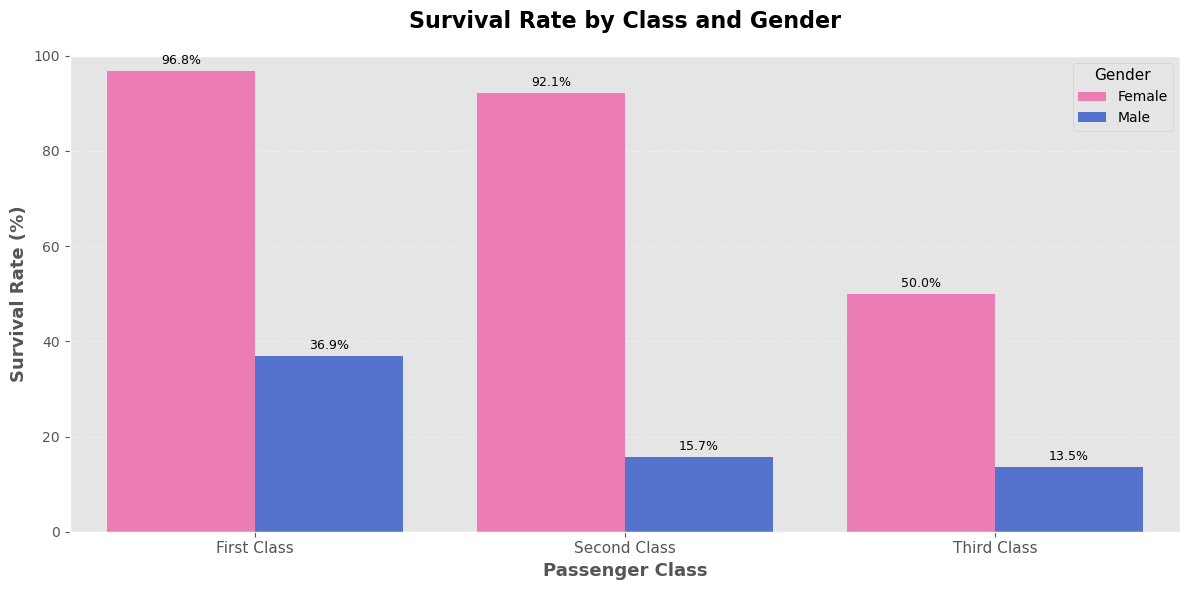

Notes:
- Women in all classes had a significantly higher survival rate than men
- Class 1 was the best for survival for both sexes
- Men in Class 3 had the lowest survival rate


In [26]:

# Chart 1: Survival rate by gender and grade
plt.figure(figsize=(12, 6))

# Creating data for drawing
survival_data = df.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100
survival_data = survival_data.reset_index()
survival_data['Sex'] = survival_data['Sex'].map({0: 'Female', 1: 'Male'})


# Sum bar graph
ax = sns.barplot(data=survival_data, x='Pclass', y='Survived', hue='Sex', palette=['#FF69B4', '#4169E1'])


# Graphic improvements
plt.title('Survival Rate by Class and Gender', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Passenger Class', fontsize=13, fontweight='bold')
plt.ylabel('Survival Rate (%)', fontsize=13, fontweight='bold')
plt.legend(title='Gender', title_fontsize=11, fontsize=10, loc='upper right')


# Adding percentages to columns
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)


# Improved axes
plt.xticks([0, 1, 2], ['First Class', 'Second Class', 'Third Class'], fontsize=11)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("Notes:")
print("- Women in all classes had a significantly higher survival rate than men")
print("- Class 1 was the best for survival for both sexes")
print("- Men in Class 3 had the lowest survival rate")

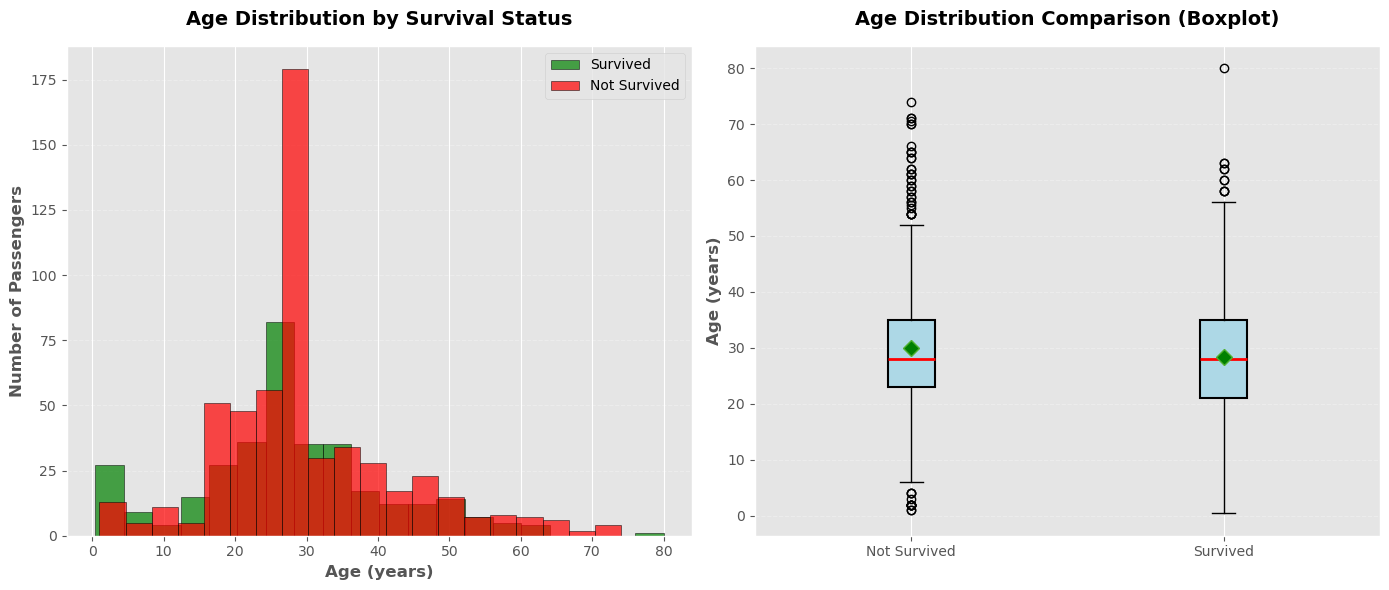

Observations:
- Children (under 10 years old) had a better chance of survival
- Age distribution is relatively similar between survivors and non-survivors
- Average age of survivors is slightly lower


In [27]:

# Chart 2: Age Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
axes[0].hist(df[df['Survived']==1]['Age'], bins=20, alpha=0.7, label='Survived', color='green', edgecolor='black')
axes[0].hist(df[df['Survived']==0]['Age'], bins=20, alpha=0.7, label='Not Survived', color='red', edgecolor='black')
axes[0].set_title('Age Distribution by Survival Status', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Age (years)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Passengers', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Boxplot
survival_labels = df['Survived'].map({0: 'Not Survived', 1: 'Survived'})
box_data = [df[df['Survived']==0]['Age'].dropna(), df[df['Survived']==1]['Age'].dropna()]
bp = axes[1].boxplot(box_data, labels=['Not Survived', 'Survived'], 
                      patch_artist=True, showmeans=True,
                      boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                      medianprops=dict(color='red', linewidth=2),
                      meanprops=dict(marker='D', markerfacecolor='green', markersize=8))

axes[1].set_title('Age Distribution Comparison (Boxplot)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Age (years)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("Observations:")
print("- Children (under 10 years old) had a better chance of survival")
print("- Age distribution is relatively similar between survivors and non-survivors")
print("- Average age of survivors is slightly lower")

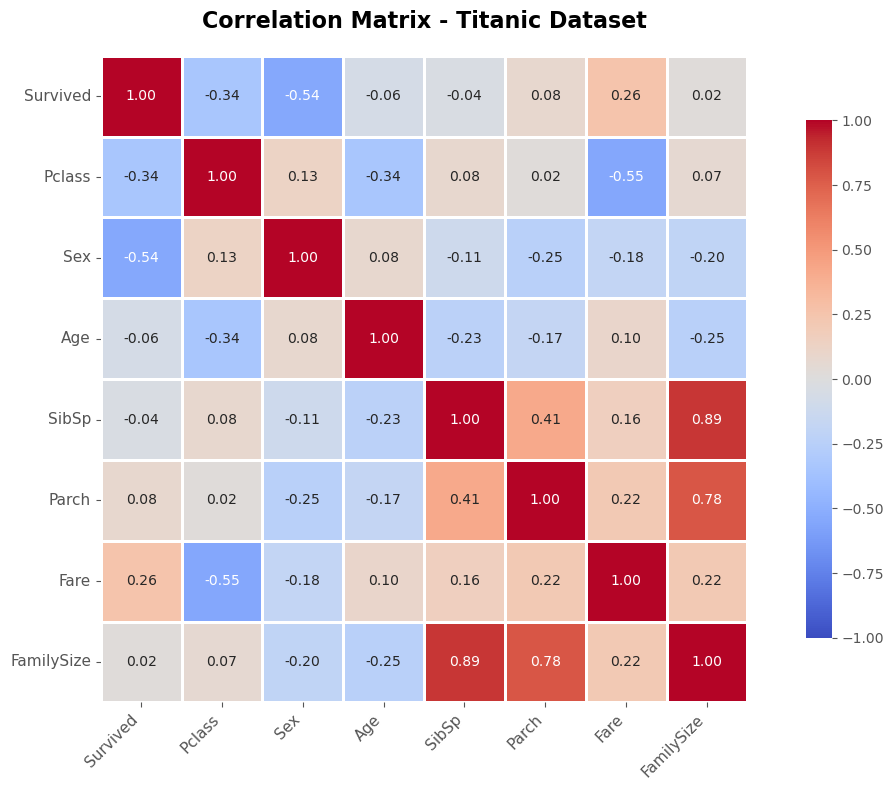

Notes:
- Strong negative correlation between Sex (Male) and Survival (-0.54)
- Negative correlation between Pclass and Survival (-0.34): Higher class means lower survival rate
- Positive correlation between Fare and Survival (+0.26): Higher price = higher chance


In [28]:

# Graph 3: Correlation Matrix
plt.figure(figsize=(12, 8))

# Calculate the link
numeric_cols = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
correlation_matrix = df[numeric_cols].corr()


# Draw heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)

plt.title('Correlation Matrix - Titanic Dataset', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

print("Notes:")
print("- Strong negative correlation between Sex (Male) and Survival (-0.54)")
print("- Negative correlation between Pclass and Survival (-0.34): Higher class means lower survival rate")
print("- Positive correlation between Fare and Survival (+0.26): Higher price = higher chance")

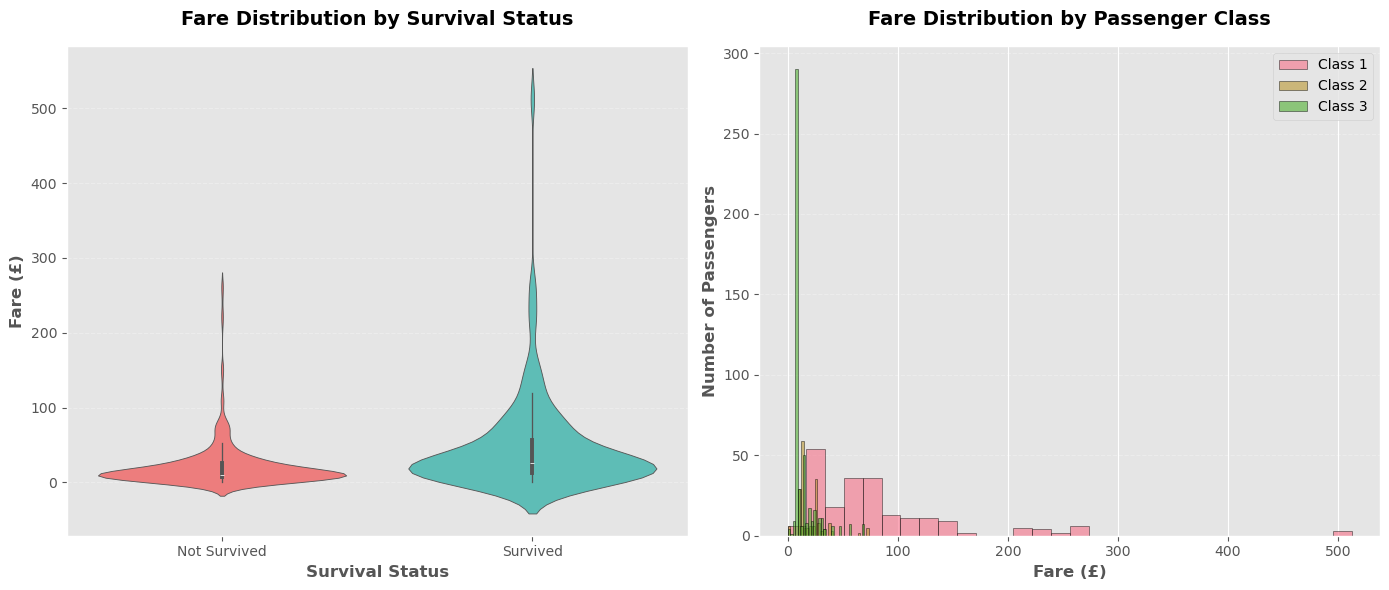

Notes:
- Those who paid higher prices had a better survival rate
- First class was significantly more expensive
- There is a large price variation within each class


In [29]:
# Additional chart: Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin Plot
survived_labels_map = {0: 'Not Survived', 1: 'Survived'}
df['Survival_Status'] = df['Survived'].map(survived_labels_map)

sns.violinplot(data=df, x='Survival_Status', y='Fare', palette=['#FF6B6B', '#4ECDC4'], ax=axes[0])
axes[0].set_title('Fare Distribution by Survival Status', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Survival Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fare (£)', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Histogram by Class
for pclass in [1, 2, 3]:
    class_data = df[df['Pclass']==pclass]['Fare']
    axes[1].hist(class_data, bins=30, alpha=0.6, label=f'Class {pclass}', edgecolor='black')

axes[1].set_title('Fare Distribution by Passenger Class', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Fare (£)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Passengers', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Delete temporary column
df.drop('Survival_Status', axis=1, inplace=True)

print("Notes:")
print("- Those who paid higher prices had a better survival rate")
print("- First class was significantly more expensive")
print("- There is a large price variation within each class")

In [30]:
# استيراد مكتبات التعلم الآلي
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

print("✅ تم استيراد مكتبات التعلم الآلي بنجاح!")

✅ تم استيراد مكتبات التعلم الآلي بنجاح!


In [31]:
# Defining the independent variables (Features) and the dependent variable (Target)
print("Selecting variables for the model:")
print("="*60)
# Removing unnecessary columns
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Survived']
X = df.drop(columns_to_drop, axis=1)
y = df['Survived']

print(f"✅ Number of independent variables (Features): {X.shape[1]}")
print(f"✅ Number of rows: {X.shape[0]}")
print(f"\n Variables used:")
print(X.columns.tolist())

print(f"\n Target variable: Survived")
print(f" - 0: Did not survive")
print(f" - 1: Survived")

Selecting variables for the model:
✅ Number of independent variables (Features): 9
✅ Number of rows: 891

 Variables used:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize']

 Target variable: Survived
 - 0: Did not survive
 - 1: Survived


In [32]:

# Divide the data into training and testing (80% - 20%)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(" Data Split:")
print("="*60)
print(f"✅ Training Data: {X_train.shape[0]} Row ({(X_train.shape[0]/len(df)*100):.1f}%)")
print(f"✅ Test Data: {X_test.shape[0]} Row ({(X_test.shape[0]/len(df)*100):.1f}%)")

print(f"\n Target Variable Distribution in Training Data:")
print(y_train.value_counts())
print(f"\n Target Variable Distribution in Test Data:")
print(y_test.value_counts())

 Data Split:
✅ Training Data: 712 Row (79.9%)
✅ Test Data: 179 Row (20.1%)

 Target Variable Distribution in Training Data:
Survived
0    439
1    273
Name: count, dtype: int64

 Target Variable Distribution in Test Data:
Survived
0    110
1     69
Name: count, dtype: int64


In [33]:
#Model 1: Logistic Regression
print("Model 1: Logistic Regression")
print("="*60)
# Create and train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
# Prediction
y_pred_lr = lr_model.predict(X_test)

# Calculate metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
print(f"✅ Model trained successfully!")
print(f"\n Model results:")
print(f" - Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f" - Precision: {lr_precision:.4f} ({lr_precision*100:.2f}%)")
print(f" - Recall: {lr_recall:.4f} ({lr_recall*100:.2f}%)")
print(f" - F1-Score: {lr_f1:.4f} ({lr_f1*100:.2f}%)")


Model 1: Logistic Regression
✅ Model trained successfully!

 Model results:
 - Accuracy: 0.8045 (80.45%)
 - Precision: 0.7931 (79.31%)
 - Recall: 0.6667 (66.67%)
 - F1-Score: 0.7244 (72.44%)


In [35]:
# Model 2: Decision Tree
print("Model 2 : Decision Tree")
print("="*60)

# Create and train the model 
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test)

# Calculate metrics 
dt_accuracy = accuracy_score(y_test, y_pred_dt)  # ← أضف هذا السطر!
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print(f"✅ Model trained successfully!")
print(f"\n Model results:")
print(f" - Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f" - Precision: {dt_precision:.4f} ({dt_precision*100:.2f}%)")
print(f" - Recall: {dt_recall:.4f} ({dt_recall*100:.2f}%)")
print(f" - F1-Score: {dt_f1:.4f} ({dt_f1*100:.2f}%)")

Model 2 : Decision Tree
✅ Model trained successfully!

 Model results:
 - Accuracy: 0.7654 (76.54%)
 - Precision: 0.7547 (75.47%)
 - Recall: 0.5797 (57.97%)
 - F1-Score: 0.6557 (65.57%)


In [36]:
# Model 3: Random Forest (Additional model for comparison)

print("="*60)

# Create and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
print(f"✅ Model trained successfully!")
print(f"\n Model results:")
print(f" - Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f" - Precision: {rf_precision:.4f} ({rf_precision*100:.2f}%)")
print(f" - Recall: {rf_recall:.4f} ({rf_recall*100:.2f}%)")
print(f" - F1-Score: {rf_f1:.4f} ({rf_f1*100:.2f}%)")

✅ Model trained successfully!

 Model results:
 - Accuracy: 0.8045 (80.45%)
 - Precision: 0.8542 (85.42%)
 - Recall: 0.5942 (59.42%)
 - F1-Score: 0.7009 (70.09%)


In [37]:
# Comparing the models
print("📊 A comprehensive comparison between the three models:")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy],
    'Precision': [lr_precision, dt_precision, rf_precision],
    'Recall': [lr_recall, dt_recall, rf_recall],
    'F1-Score': [lr_f1, dt_f1, rf_f1]
})

#Display format
comparison_df = comparison_df.round(4)
print(comparison_df.to_string(index=False))

# Determine the best model
best_model_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_accuracy = comparison_df.loc[best_model_idx, 'Accuracy']


print(f"\n Best Model: {best_model_name}")
print(f" Accuracy: {best_accuracy: .4f} ({best_accuracy*100: .2f}%)")

📊 A comprehensive comparison between the three models:
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8045     0.7931  0.6667    0.7244
      Decision Tree    0.7654     0.7547  0.5797    0.6557
      Random Forest    0.8045     0.8542  0.5942    0.7009

 Best Model: Logistic Regression
 Accuracy:  0.8045 ( 80.45%)


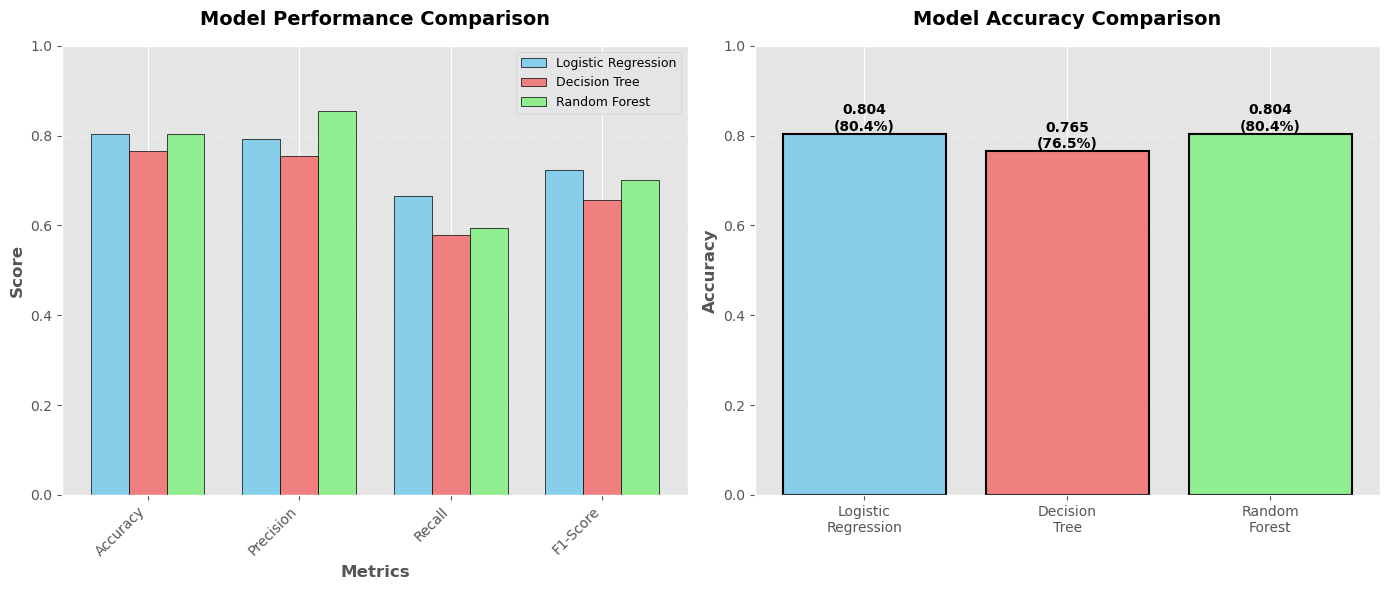

✅ Model comparison successfully plotted!


In [38]:
# Model Comparison Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First Graph: Measurement Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

axes[0].bar(x - width, [lr_accuracy, lr_precision, lr_recall, lr_f1], 
            width, label='Logistic Regression', color='skyblue', edgecolor='black')
axes[0].bar(x, [dt_accuracy, dt_precision, dt_recall, dt_f1], 
            width, label='Decision Tree', color='lightcoral', edgecolor='black')
axes[0].bar(x + width, [rf_accuracy, rf_precision, rf_recall, rf_f1], 
            width, label='Random Forest', color='lightgreen', edgecolor='black')

axes[0].set_xlabel('Metrics', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, 1)

# Second drawing: Accuracy only
models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
accuracies = [lr_accuracy, dt_accuracy, rf_accuracy]
colors_acc = ['skyblue', 'lightcoral', 'lightgreen']

bars = axes[1].bar(models, accuracies, color=colors_acc, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Add values above the columns
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}\n({height*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Model comparison successfully plotted!")

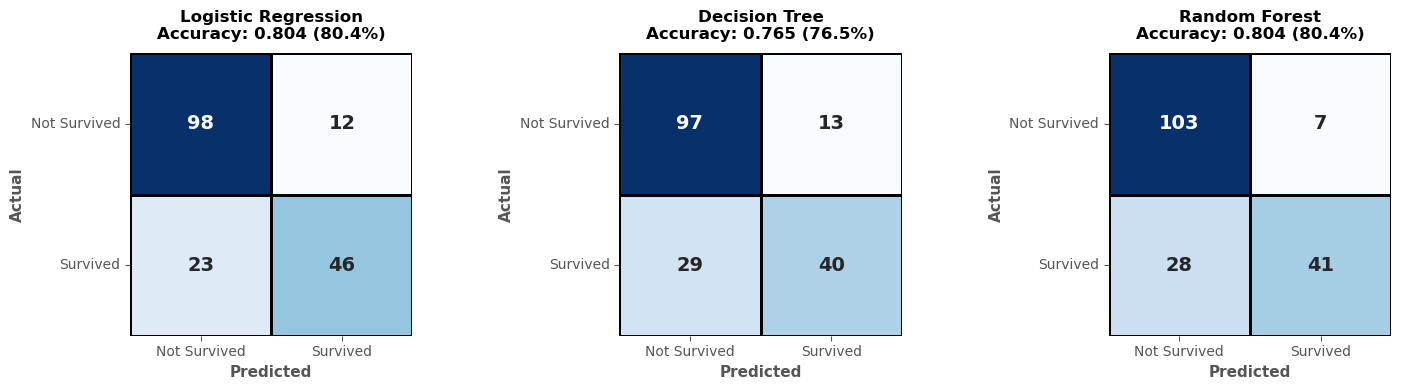

Confusion Matrix Explanation:
 - True Negative (TN): Correct prediction - did not survive
 - False Positive (FP): Incorrect prediction - predicted survival but did not
 - False Negative (FN): Incorrect prediction - predicted not to survive but did
 - True Positive (TP): Correct prediction - survived


In [39]:
# Drawing the Confusion Matrix for the three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_data = [
    ('Logistic Regression', y_pred_lr, lr_accuracy),
    ('Decision Tree', y_pred_dt, dt_accuracy),
    ('Random Forest', y_pred_rf, rf_accuracy)
]

for idx, (model_name, y_pred, accuracy) in enumerate(models_data):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                ax=axes[idx], square=True, linewidths=2, linecolor='black',
                annot_kws={'fontsize': 14, 'fontweight': 'bold'})
    
    axes[idx].set_title(f'{model_name}\nAccuracy: {accuracy:.3f} ({accuracy*100:.1f}%)', 
                        fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_ylabel('Actual', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=11, fontweight='bold')
    axes[idx].set_xticklabels(['Not Survived', 'Survived'], fontsize=10)
    axes[idx].set_yticklabels(['Not Survived', 'Survived'], fontsize=10, rotation=0)

plt.tight_layout()
plt.show()

print("Confusion Matrix Explanation:")
print(" - True Negative (TN): Correct prediction - did not survive")
print(" - False Positive (FP): Incorrect prediction - predicted survival but did not")
print(" - False Negative (FN): Incorrect prediction - predicted not to survive but did")
print(" - True Positive (TP): Correct prediction - survived")

In [40]:
# Detailed report on the best model (Random Forest)
print("Classification Report - Random Forest (الأفضل):")
print("="*70)

report = classification_report(y_test, y_pred_rf, 
                               target_names=['Not Survived', 'Survived'],
                               digits=4)
print(report)
print("\n Explanation of terms:")
print(" - Precision: Of all the positive predictions, how many were correct?")
print(" - Recall: Of all the actual positive cases, how many did we detect?")
print(" - F1-Score: The harmonic mean between Precision and Recall")
print(" - Support: The number of actual cases in each category")

Classification Report - Random Forest (الأفضل):
              precision    recall  f1-score   support

Not Survived     0.7863    0.9364    0.8548       110
    Survived     0.8542    0.5942    0.7009        69

    accuracy                         0.8045       179
   macro avg     0.8202    0.7653    0.7778       179
weighted avg     0.8124    0.8045    0.7954       179


 Explanation of terms:
 - Precision: Of all the positive predictions, how many were correct?
 - Recall: Of all the actual positive cases, how many did we detect?
 - F1-Score: The harmonic mean between Precision and Recall
 - Support: The number of actual cases in each category


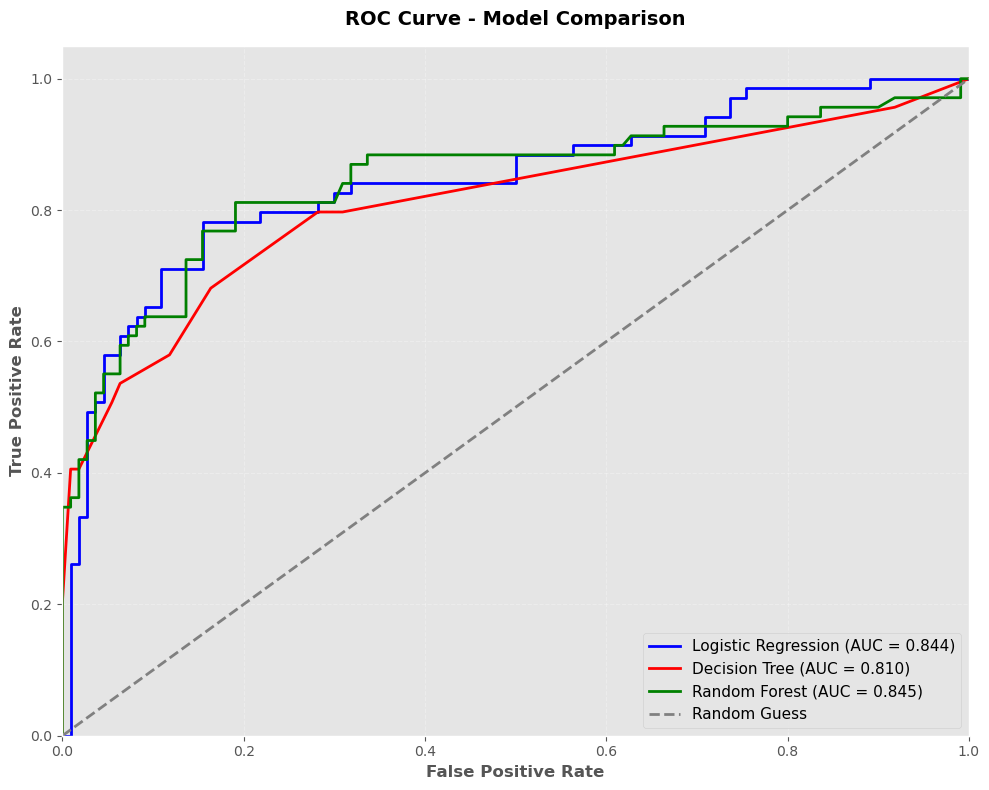

📊 ROC AUC Scores:
   - Logistic Regression: 0.8443
   - Decision Tree:       0.8101
   - Random Forest:       0.8449


In [41]:
# ROC Curve drawing for the three models
plt.figure(figsize=(10, 8))
# Calculating prediction probabilities
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# ROC calculation
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_dt = auc(fpr_dt, tpr_dt)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Drawing curves
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, 
         label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt, color='red', lw=2, 
         label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, 
         label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Model Comparison', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("📊 ROC AUC Scores:")
print(f"   - Logistic Regression: {roc_auc_lr:.4f}")
print(f"   - Decision Tree:       {roc_auc_dt:.4f}")
print(f"   - Random Forest:       {roc_auc_rf:.4f}")